In [2]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import math
import seaborn as sns
import os

item_path = r"D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\dataset\sales_pers.item_chunk_0.parquet"
df_item = pl.read_parquet(item_path)


# **Task 1:** Phân tích đơn biến

## Thống kê

In [3]:
#Dataframe item
df_item = pl.read_parquet(item_path)
print(df_item.shape)

(27332, 34)


In [4]:
#Xem trước data
df_item.head(5)

p_id,item_id,price,category_l1_id,category_l1,category_l2_id,category_l2,category_l3_id,category_l3,category_id,category,description,brand,manufacturer,creation_timestamp,is_deleted,created_date,updated_date,sync_status_id,last_sync_date,sync_error_message,image_url,gender_target,age_group,item_type,gp,weight,color,size,origin,volume,material,sale_status,description_new
i32,str,"decimal[38,4]",i32,str,i32,str,i32,str,i32,str,str,str,str,i64,bool,datetime[μs],datetime[μs],i32,datetime[μs],str,str,str,str,str,"decimal[38,4]",f32,str,str,str,str,str,i32,str
17065,"""0502020000004""",99000.0000,1,"""Babycare""",35,"""Bình sữa, phụ kiện""",7050,"""Núm ty""",7058,"""Núm ty Dr Brown""","""Không xác định""","""Dr.Brown's""","""Không xác định""",1333531544,false,2012-04-04 09:25:44.240,2025-08-18 09:59:19.847,2,2025-07-18 17:59:29.898256,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",36828.0000,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",0,"""Chi tiết sản phẩm …"
72370,"""0010290040150""",69000.0000,3292,"""Thời trang""",3958,"""Cơ cấu hàng cũ""",7007,"""Thời trang bé trai, bé gái cũ""",6987,"""Bộ quần áo bé gái""","""Không xác định""","""Con Cưng""","""Không xác định""",1503046250,false,2017-08-18 08:50:50.713,2025-09-18 16:05:42.360,null,null,null,"""Không xác định""","""Bé Gái""","""Từ 3Y""","""Bộ quần áo""",0.0000,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",0,"""Không xác định"""
31154,"""0008010000015""",45000.0000,351,"""Đồ chơi & Sách""",2033,"""0-1Y""",2118,"""Gặm nướu""",2121,"""Gặm nướu khác""","""- Chất liệu: Sản phẩm được làm…","""Thương hiệu khác""","""Không xác định""",1358501584,false,2013-01-18 09:33:04.260,2025-09-27 00:05:36.233,2,2025-07-18 17:59:29.898256,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",14490.0000,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",0,"""Chi tiết sản phẩm …"
46123,"""0020010000094""",401000.0000,2222,"""Tã""",2272,"""Merries""",2275,"""Merries""",2276,"""Merries_Sơ Sinh""","""﻿﻿Tã dán Merries size S 82 miế…","""Merries Nhật""","""Không xác định""",1400062039,false,2014-05-14 10:07:19.603,2025-09-27 00:05:36.233,2,2025-07-18 17:59:29.898256,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",59749.0000,null,"""Không xác định""","""Không xác định""","""Nhật Bản, Nhật Bản""","""Không xác định""","""Giấy, bột giấy, vải không dệt,…",0,"""Không xác định"""
46127,"""0020010000098""",401000.0000,2222,"""Tã""",2272,"""Merries""",2275,"""Merries""",2278,"""Merries_Tã Quần""","""﻿﻿﻿Bỉm tã quần Merries size M …","""Merries Nhật""","""Không xác định""",1400062040,false,2014-05-14 10:07:20.370,2025-09-27 00:05:36.233,2,2025-07-18 17:59:29.898256,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",65764.0000,null,"""Không xác định""","""Không xác định""","""Nhật Bản, Nhật Bản""","""Không xác định""","""Giấy, bột giấy, vải không dệt,…",0,"""Không xác định"""


In [6]:
pl.Config.set_tbl_rows(50)             # số dòng tối đa hiển thị
pl.Config.set_tbl_cols(20)             # số cột tối đa hiển thị
pl.Config.set_tbl_width_chars(200)     # tổng chiều rộng bảng ký tự
pl.Config.set_fmt_str_lengths(200)     # độ dài chuỗi tối đa hiển thị (quan trọng nhất!)

polars.config.Config

In [7]:
#Kiem tra unique count
cols_to_check = df_item.columns

unique_counts = []
for col in cols_to_check:
    n = df_item.select(pl.col(col).n_unique()).item()   # cách lấy giá trị n_unique đúng của Polars
    unique_counts.append((col, n))


df_unique = (
    pl.DataFrame(unique_counts, schema=["column", "unique_count"])
    .sort("unique_count", descending=True)
)

print(df_unique)

output_dir = r"D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\statistics"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "unique_counts.csv")


df_unique.write_csv(output_path)
print(f"Unique count saved to: {output_path}")



shape: (34, 2)
┌────────────────────┬──────────────┐
│ column             ┆ unique_count │
│ ---                ┆ ---          │
│ str                ┆ i64          │
╞════════════════════╪══════════════╡
│ p_id               ┆ 27332        │
│ item_id            ┆ 27332        │
│ created_date       ┆ 12108        │
│ creation_timestamp ┆ 10836        │
│ description_new    ┆ 9502         │
│ gp                 ┆ 9090         │
│ description        ┆ 8583         │
│ category_id        ┆ 1833         │
│ category           ┆ 1651         │
│ brand              ┆ 976          │
│ manufacturer       ┆ 758          │
│ price              ┆ 733          │
│ material           ┆ 583          │
│ category_l3_id     ┆ 523          │
│ category_l3        ┆ 470          │
│ origin             ┆ 293          │
│ updated_date       ┆ 286          │
│ item_type          ┆ 195          │
│ category_l2_id     ┆ 139          │
│ volume             ┆ 138          │
│ category_l2        ┆ 134         

C:\Users\PC\AppData\Local\Temp\ipykernel_23080\2728206775.py:11: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  pl.DataFrame(unique_counts, schema=["column", "unique_count"])


In [8]:
# Hàm tính % "Không xác định" và % NULL cho toàn bộ cột
def compute_unknown_null_ratio(df: pl.DataFrame):
    results = []

    n = df.height

    for col in df.columns:
        series = df[col]

        # Tính số lượng NULL
        null_count = series.null_count()

        # Nếu là string -> kiểm tra "Không xác định"
        if series.dtype == pl.String:
            unknown_count = (series == "Không xác định").sum()
        else:
            unknown_count = 0

        results.append({
            "column": col,
            "dtype": str(series.dtype),
            "null_count": null_count,
            "null_ratio(%)": round(null_count / n * 100, 2),
            "unknown_count": unknown_count,
            "unknown_ratio(%)": round(unknown_count / n * 100, 2)
        })

    return pl.DataFrame(results).sort("unknown_ratio(%)", descending=True)

# Gọi hàm
missing_report = compute_unknown_null_ratio(df_item)

print(missing_report)


shape: (34, 6)
┌────────────────────┬──────────────────────────────────────────┬────────────┬───────────────┬───────────────┬──────────────────┐
│ column             ┆ dtype                                    ┆ null_count ┆ null_ratio(%) ┆ unknown_count ┆ unknown_ratio(%) │
│ ---                ┆ ---                                      ┆ ---        ┆ ---           ┆ ---           ┆ ---              │
│ str                ┆ str                                      ┆ i64        ┆ f64           ┆ i64           ┆ f64              │
╞════════════════════╪══════════════════════════════════════════╪════════════╪═══════════════╪═══════════════╪══════════════════╡
│ image_url          ┆ String                                   ┆ 0          ┆ 0.0           ┆ 27332         ┆ 100.0            │
│ volume             ┆ String                                   ┆ 0          ┆ 0.0           ┆ 26973         ┆ 98.69            │
│ color              ┆ String                                   ┆ 0        

In [9]:
df_describe = df_item.select(["price", "gp", "weight"]).describe()
print(df_describe)


output_path = os.path.join(output_dir, "numeric_describe_price_gp_weight.csv")
df_describe.write_csv(output_path)
print(f"Describe result saved to: {output_path}")


shape: (9, 4)
┌────────────┬───────────────┬──────────────┬─────────┐
│ statistic  ┆ price         ┆ gp           ┆ weight  │
│ ---        ┆ ---           ┆ ---          ┆ ---     │
│ str        ┆ f64           ┆ f64          ┆ f64     │
╞════════════╪═══════════════╪══════════════╪═════════╡
│ count      ┆ 27332.0       ┆ 27332.0      ┆ 0.0     │
│ null_count ┆ 0.0           ┆ 0.0          ┆ 27332.0 │
│ mean       ┆ 190456.829467 ┆ 49696.651226 ┆ null    │
│ std        ┆ 511123.971813 ┆ 144155.68753 ┆ null    │
│ min        ┆ 0.0           ┆ 0.0          ┆ null    │
│ 25%        ┆ 49000.0       ┆ 0.0          ┆ null    │
│ 50%        ┆ 119000.0      ┆ 25047.0      ┆ null    │
│ 75%        ┆ 199000.0      ┆ 65532.0      ┆ null    │
│ max        ┆ 2.099e7       ┆ 5.54136e6    ┆ null    │
└────────────┴───────────────┴──────────────┴─────────┘
Describe result saved to: D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\statistics\numeric_describe_price_gp_weight.csv


In [10]:
output_folder = r"D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\statistics"
os.makedirs(output_folder, exist_ok=True)

id_cols = [
    "p_id", "item_id",
    "category_l1_id", "category_l2_id", "category_l3_id", "category_id",
    "creation_timestamp"
]
numeric_cols = ["price", "gp", "weight"]
all_cols = df_item.columns
categorical_cols = [c for c in all_cols if c not in id_cols and c not in numeric_cols]

# Duyệt từng cột và thống kê
for col in categorical_cols:
    try:
        # Đếm tần suất
        vc = df_item[col].value_counts().sort("count", descending=True)

        # In top 5 ra màn hình
        print(f"\n Tần suất giá trị cho cột {col}:")
        print(vc.head(10))

        # Lưu full bảng tần suất xuống file CSV
        file_path = os.path.join(output_folder, f"{col}_value_counts.csv")
        vc.write_csv(file_path)
        print(f" Đã lưu vào file: {file_path}\n")

    except Exception as e:
        print(f" Lỗi khi xử lý cột {col}: {e}")



 Tần suất giá trị cho cột category_l1:
shape: (10, 2)
┌────────────────────────┬───────┐
│ category_l1            ┆ count │
│ ---                    ┆ ---   │
│ str                    ┆ u32   │
╞════════════════════════╪═══════╡
│ Thời trang             ┆ 15042 │
│ Phụ kiện               ┆ 3147  │
│ Đồ chơi & Sách         ┆ 2955  │
│ Babycare               ┆ 1994  │
│ Thực phẩm cho bé       ┆ 981   │
│ Textile                ┆ 555   │
│ Thực phẩm cho gia đình ┆ 470   │
│ Tã                     ┆ 442   │
│ Sữa                    ┆ 437   │
│ Hóa mỹ phẩm gia đình   ┆ 388   │
└────────────────────────┴───────┘
 Đã lưu vào file: D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\statistics\category_l1_value_counts.csv


 Tần suất giá trị cho cột category_l2:
shape: (10, 2)
┌────────────────────────────┬───────┐
│ category_l2                ┆ count │
│ ---                        ┆ ---   │
│ str                        ┆ u32   │
╞════════════════════════════╪═══════╡
│ Cơ c

### Nhận xét sau quá trình Thống kê đơn biến: 
**Về unique:**
- Một số biến có độ unique rất cao, như: 
    + description_new: 9,502 unique
    + description: 8,583 unique
    + brand: 976 unique
    + manufacturer: 758 unique
    + material: 583 unique

→ Đây là các trường rất giàu thông tin nhưng phân tán cao

- Một số trường hợp gần như không có đa dạng biến: 
    +  last_sync_date,4
    + sync_status_id,2
    + sale_status,2
    + is_deleted,1
    + sync_error_message,1
    + image_url,1
    + weight,1
    
→ Không cung cấp được thông tin

**Về phân bổ tần suất (value counts):**
- Một số biến có độ thiên lệch lớn: 
    + category_l1 có Thời trang: 15,042
    + brand có Animo: 8,149, CF (ConCung Fashion): 5,426 còn lại gần như không đáng kể
- Một số biến có missing value rất cao: 
    + volume: 26,973 “Không xác định”
    + material: 24,664 “Không xác định”
    + color: 26,608 “Không xác định”
    + size: 25,108 “Không xác định”
    + gender_target: 18,038 “Không xác định"
    + age_group: 15,812 “Không xác định"

## Trực quan hóa dữ liệu

 Đã lưu biểu đồ vào: D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\visualize\univariate\price_gp_distribution.png


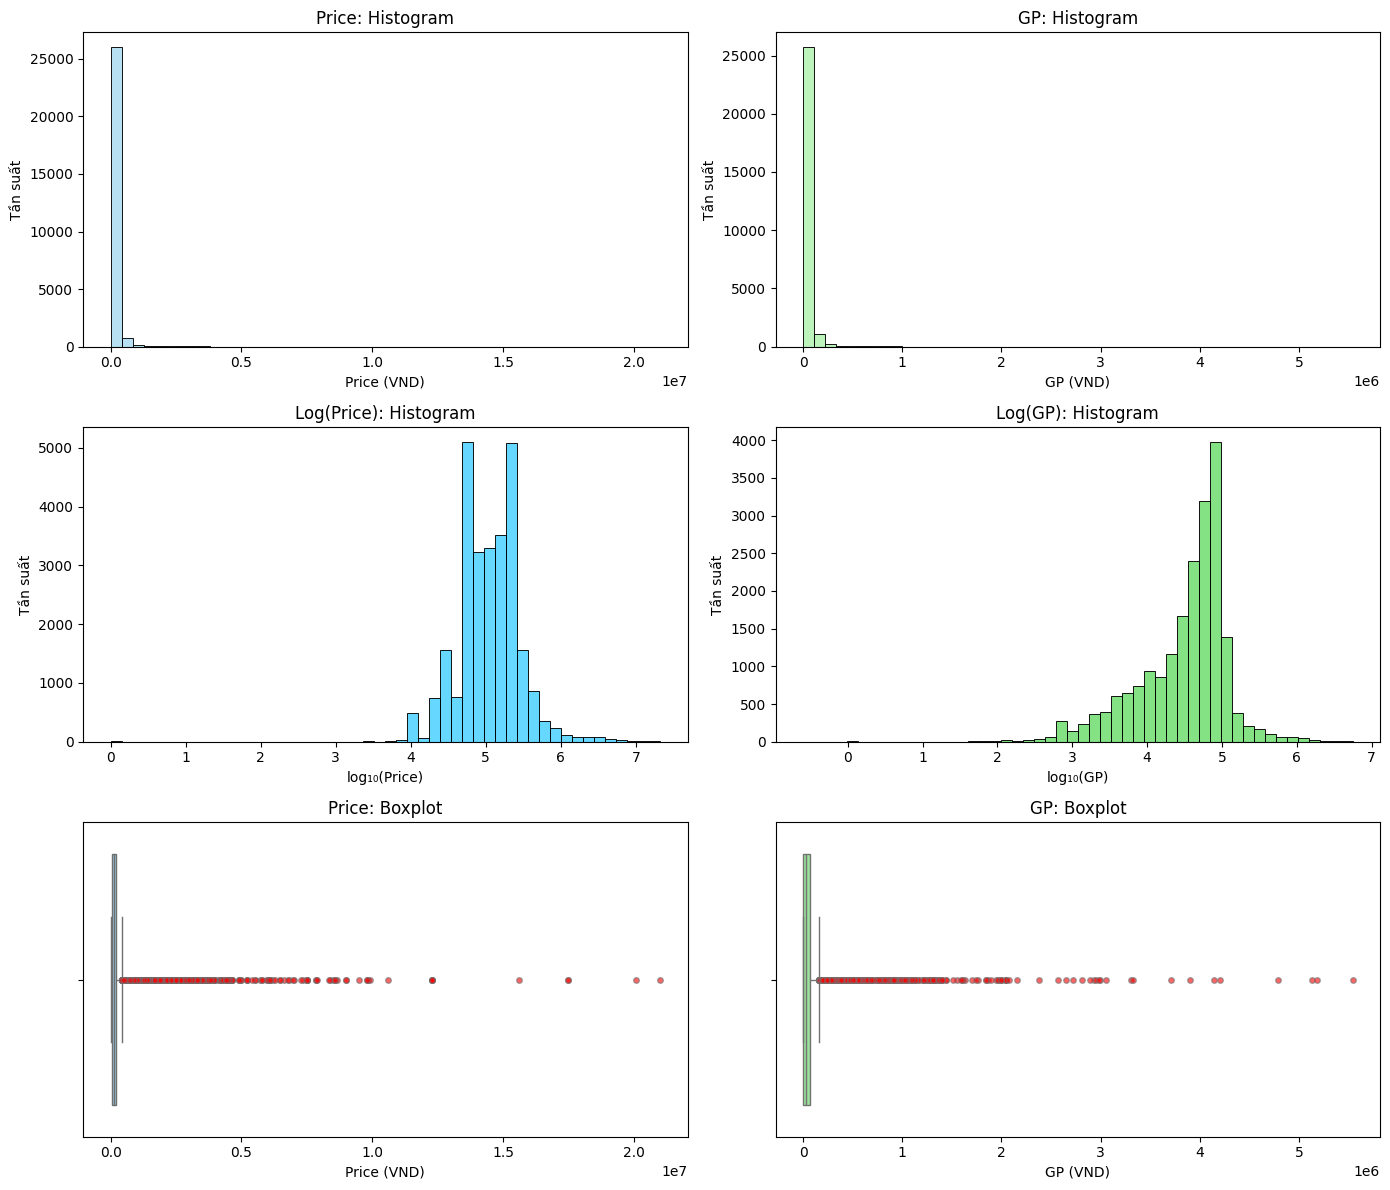

In [11]:
output_folder = r"D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\visualize\univariate"
os.makedirs(output_folder, exist_ok=True)

# --- Tạo dataframe số liệu ---
df_num = (
    df_item
    .select([
        pl.col("price"),
        pl.col("gp"),
        pl.col("price").log10().alias("log_price"),
        pl.col("gp").log10().alias("log_gp")
    ])
    .drop_nulls()
)

# --- Trích dữ liệu ra numpy ---
price = df_num["price"].to_numpy().flatten()
gp = df_num["gp"].to_numpy().flatten()
log_price = df_num["log_price"].to_numpy().flatten()
log_gp = df_num["log_gp"].to_numpy().flatten()

# --- Vẽ 3 hàng × 2 cột ---
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Hàng 1: Histogram gốc
sns.histplot(price, bins=50, color="skyblue", edgecolor="black", ax=axes[0,0], alpha=0.6)
axes[0,0].set_title("Price: Histogram")
axes[0,0].set_xlabel("Price (VND)")
axes[0,0].set_ylabel("Tần suất")

sns.histplot(gp, bins=50, color="lightgreen", edgecolor="black", ax=axes[0,1], alpha=0.6)
axes[0,1].set_title("GP: Histogram")
axes[0,1].set_xlabel("GP (VND)")
axes[0,1].set_ylabel("Tần suất")

# Hàng 2: Histogram log
sns.histplot(log_price, bins=50, color="deepskyblue", edgecolor="black", ax=axes[1,0], alpha=0.6)
axes[1,0].set_title("Log(Price): Histogram")
axes[1,0].set_xlabel("log₁₀(Price)")
axes[1,0].set_ylabel("Tần suất")

sns.histplot(log_gp, bins=50, color="limegreen", edgecolor="black", ax=axes[1,1], alpha=0.6)
axes[1,1].set_title("Log(GP): Histogram")
axes[1,1].set_xlabel("log₁₀(GP)")
axes[1,1].set_ylabel("Tần suất")

# Hàng 3: Boxplot
sns.boxplot(x=price, ax=axes[2,0], color="skyblue",
            flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.6))
axes[2,0].set_title("Price: Boxplot")
axes[2,0].set_xlabel("Price (VND)")

sns.boxplot(x=gp, ax=axes[2,1], color="lightgreen",
            flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.6))
axes[2,1].set_title("GP: Boxplot")
axes[2,1].set_xlabel("GP (VND)")

plt.tight_layout()

# --- Lưu ảnh xuống ---
save_path = os.path.join(output_folder, "price_gp_distribution.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f" Đã lưu biểu đồ vào: {save_path}")

plt.show()

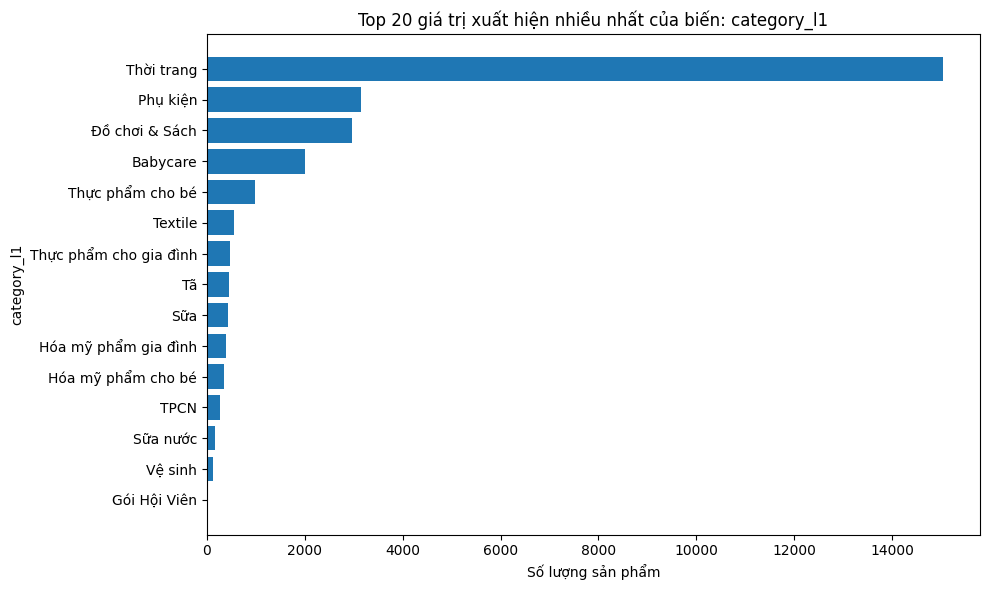

Đã lưu biểu đồ vào: D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\visualize\univariate\category_l1_top20_barchart.png


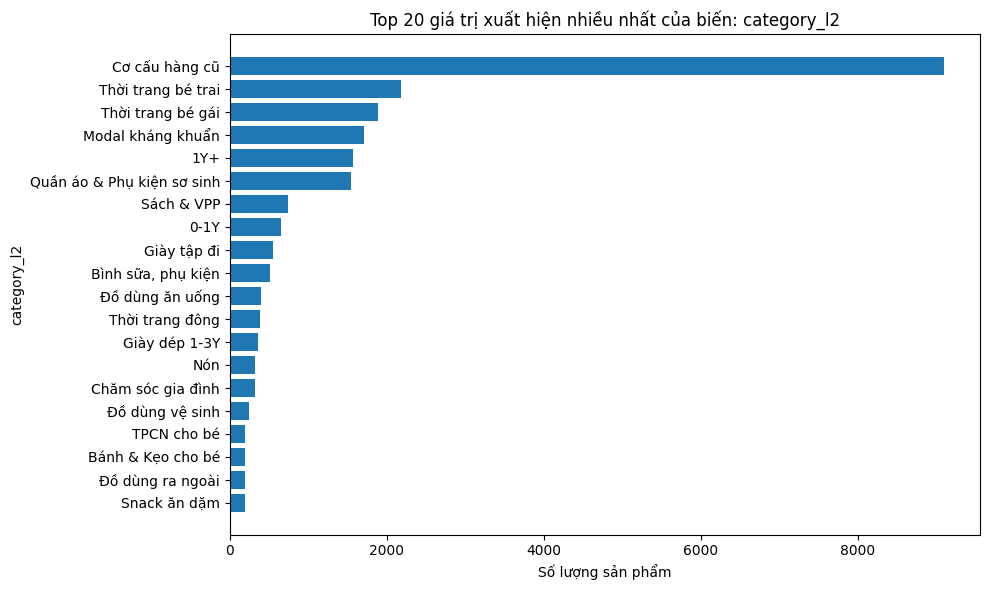

Đã lưu biểu đồ vào: D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\visualize\univariate\category_l2_top20_barchart.png


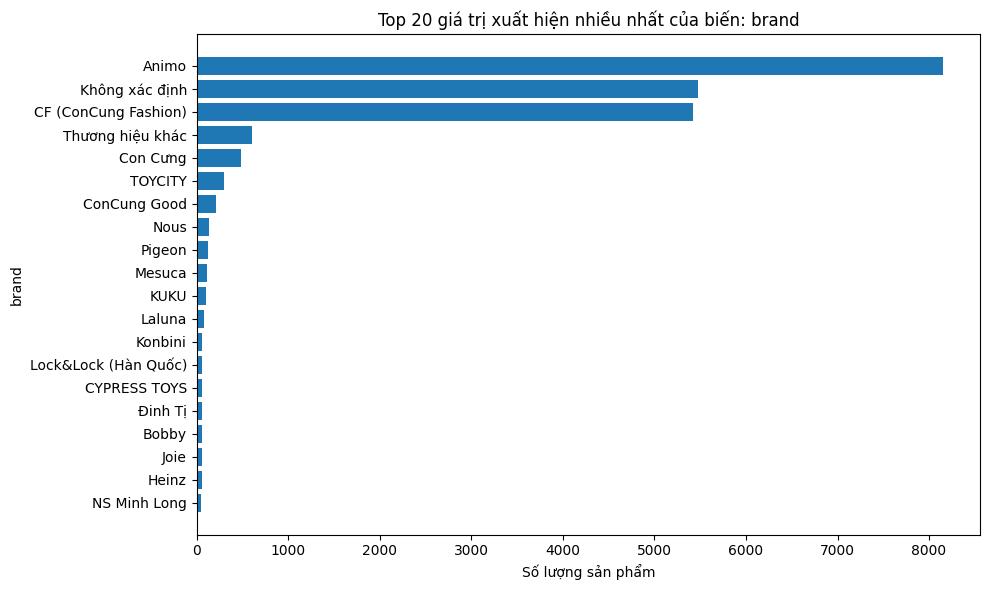

Đã lưu biểu đồ vào: D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\visualize\univariate\brand_top20_barchart.png


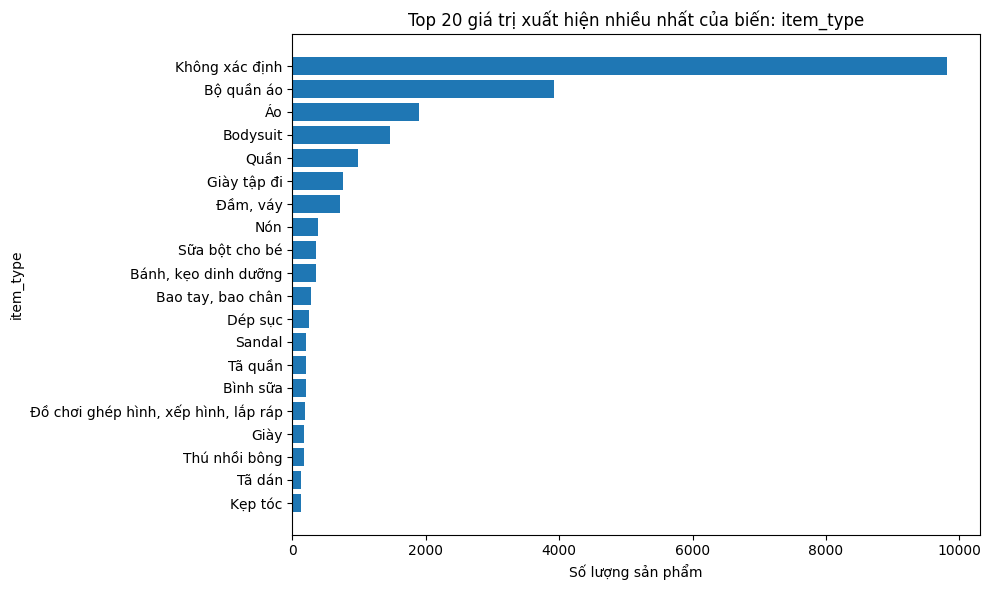

Đã lưu biểu đồ vào: D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\visualize\univariate\item_type_top20_barchart.png


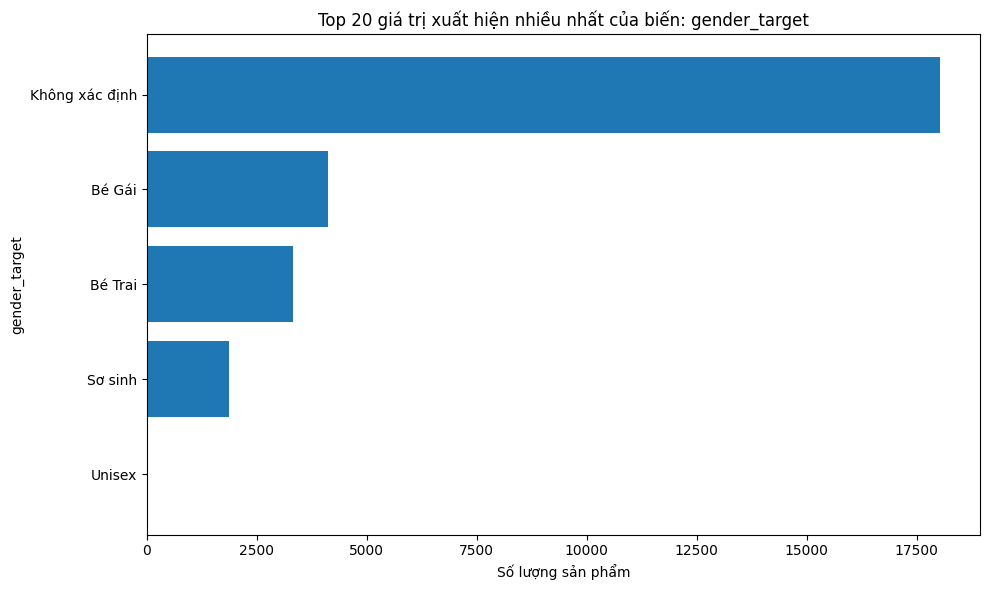

Đã lưu biểu đồ vào: D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\visualize\univariate\gender_target_top20_barchart.png


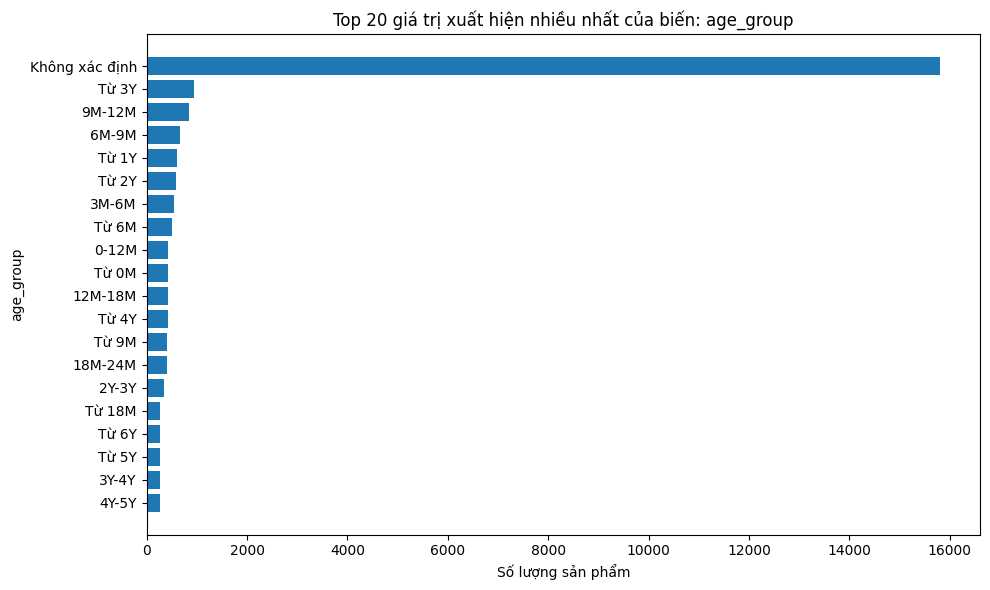

Đã lưu biểu đồ vào: D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\visualize\univariate\age_group_top20_barchart.png


In [12]:
# Tạo hàm visualize categorical (TOP 10)
def plot_categorical(df, column_name, save_dir, top_n=20):
    """
    Vẽ bar chart ngang cho 1 biến categorical (TOP N) và lưu file PNG.
    """

    # Tạo thư mục nếu chưa có
    os.makedirs(save_dir, exist_ok=True)

    # Lấy value_counts
    cat_counts = (
        df[column_name]
        .value_counts()
        .sort("count", descending=True)
        .head(top_n)  # Chỉ lấy TOP N
    )

    labels = cat_counts[column_name].to_list()
    counts = cat_counts["count"].to_list()

    # Vẽ biểu đồ
    plt.figure(figsize=(10, 6))
    plt.barh(labels[::-1], counts[::-1])  # đảo để giá trị lớn nằm trên
    plt.title(f"Top {top_n} giá trị xuất hiện nhiều nhất của biến: {column_name}")
    plt.xlabel("Số lượng sản phẩm")
    plt.ylabel(column_name)
    plt.tight_layout()

    # Đường dẫn lưu file
    save_path = os.path.join(save_dir, f"{column_name}_top{top_n}_barchart.png")

    # Lưu trước rồi show
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Đã lưu biểu đồ vào: {save_path}")



# -----------------------------------------------------------------
# CHẠY HÀM CHO 6 BIẾN CATEGORICAL
# -----------------------------------------------------------------

output_folder = r"D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\visualize\univariate"

categorical_vars = [
    "category_l1",
    "category_l2",
    "brand",
    "item_type",
    "gender_target",
    "age_group"
]

for col in categorical_vars:
    plot_categorical(df_item, col, output_folder)

### Nhận xét sơ lượt sau khi visualize:
Về category_l1
- Thời trang chiếm tỷ trọng lớn nhất và vượt trội rõ rệt so với các danh mục còn lại.
- Babycare, Phụ kiện, Đồ chơi & Sách cũng chiếm tỷ trọng đáng kể nhưng thấp hơn nhiều so với Thời trang
- Một số ngành như Sữa, Tã, Thực phẩm cho bé xuất hiện rất ít.

Về category_l2
- Cơ cấu hàng cũ chiếm phần lớn và vượt trội so với các mục còn lại 
- Một số nhóm như Thời trang bé trai, Thời trang bé gái, Modal kháng khuẩn cũng có tần suất rất cao.
- Có rất nhiều nhóm ít sản phẩm → phân phối lệch mạnh.

Về brand:
- Animo, CF (ConCung Fashion) chiếm lượng sản phẩm rất lớn.
- Không xác định vẫn chiếm tỉ lệ đáng kể → chất lượng dữ liệu thương hiệu chưa cao
- Các thương hiệu quốc tế (Pigeon, Mesuca…) có phân bổ thấp hơn nhiều

Về các biến còn lại
- Tỷ lệ "Không xác định" chiến rất cao
- Tuy nhiên, nếu xử lý được phần này thì các loại khác khá cân bằng, không bị thiên lệch.

# **Task 2:** Phân tích đa biến

Trong phân tích đa biến, nhóm chỉ sử dụng category_l1 và category_l2 (trong 4 features category có trong data) vì đây là hai cấp phân loại mang tính tổng quát và ổn định, đại diện cho cấu trúc ngành hàng và nhóm hàng lớn. Các cấp chi tiết hơn như category_l3 và category có số lượng unique rất cao (523 và 1.651 giá trị), nhiều nhóm có số lượng sản phẩm rất nhỏ, dẫn đến việc phân tích đa biến bằng boxplot hoặc crosstab trở nên nhiễu, không cho insight có giá trị.

## Thống kê

In [14]:
# Đường dẫn lưu file thống kê
output_folder = r"D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\statistics"
os.makedirs(output_folder, exist_ok=True)

# Thống kê giá theo danh mục cấp 1
price_cat_l1 = (
    df_item
    .group_by("category_l1")   # <<< SỬA Ở ĐÂY
    .agg([
        pl.count().alias("count"),
        pl.col("price").mean().alias("price_mean"),
        pl.col("price").median().alias("price_median"),
        pl.col("price").min().alias("price_min"),
        pl.col("price").max().alias("price_max"),
        pl.col("price").std().alias("price_std")
    ])
    .sort("count", descending=True)
)

# Xuất ra màn hình
print(price_cat_l1)

# Lưu file CSV
save_path = os.path.join(output_folder, "price_by_category_l1.csv")
price_cat_l1.write_csv(save_path)

print(f"\nĐã lưu thống kê vào: {save_path}")

shape: (15, 7)
┌────────────────────────┬───────┬───────────────┬──────────────┬───────────────┬───────────────┬───────────────┐
│ category_l1            ┆ count ┆ price_mean    ┆ price_median ┆ price_min     ┆ price_max     ┆ price_std     │
│ ---                    ┆ ---   ┆ ---           ┆ ---          ┆ ---           ┆ ---           ┆ ---           │
│ str                    ┆ u32   ┆ f64           ┆ f64          ┆ decimal[38,4] ┆ decimal[38,4] ┆ f64           │
╞════════════════════════╪═══════╪═══════════════╪══════════════╪═══════════════╪═══════════════╪═══════════════╡
│ Thời trang             ┆ 15042 ┆ 129943.292115 ┆ 119000.0     ┆ 9000.0000     ┆ 499000.0000   ┆ 89116.881329  │
│ Phụ kiện               ┆ 3147  ┆ 96880.521131  ┆ 89000.0      ┆ 9000.0000     ┆ 345000.0000   ┆ 69417.435707  │
│ Đồ chơi & Sách         ┆ 2955  ┆ 223563.960068 ┆ 139000.0     ┆ 1.0000        ┆ 4200000.0000  ┆ 354490.48492  │
│ Babycare               ┆ 1994  ┆ 680557.148947 ┆ 153000.0     ┆ 1000.00

C:\Users\PC\AppData\Local\Temp\ipykernel_23080\3721291180.py:10: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("count"),


### Nhận xét
Mỗi nhóm danh mục cấp 1 có mức giá trung bình rất khác nhau
- “Babycare”, “Sữa”, “Tã” có mức giá trung bình cao → đây đều là những sản phẩm cho trẻ em, thường là hàng có biên lợi nhuận cao
- “Thời trang”, “Phụ kiện”, “Thực phẩm cho bé” có mức giá trung bình thấp → nhóm sản phẩm đại trà, giá rẻ – trung bình.

→ Mô hình gợi ý cần hiểu: khách mua thời trang có hành vi giá khác hoàn toàn so với khách mua sữa/tã.

Về độ lệch chuẩn giá
- Babycare có độ lệch chuẩn gần như rất lớn: std = 1.6 triệu 
- Trong cùng một danh mục, sự phân hóa giá là rất rộng → có nhiều phân cấp giá trị khác nhau (giá rẻ → bình dân → cao cấp).

→ Nên phân cụm sản phaamr dựa trên mức giá. Qua đó, Gợi ý sản phẩm nên phù hợp với khả năng chi trả của từng user, thay vì gợi ý ngẫu nhiên trong ngành.

Về danh mục "Thời trang"
- Giá thời trang phân bố rất đều, giá median = 119k
- Thị trường thời trang trẻ em chủ lực, mức giá tầm trung
- Tuy nhiên, “Không xác định” ở color, size, material rất nhiều → có thể gây thiếu data cho việc recommendation ngành thời trang.

→ Với ngành thời trang, mô hình có thể gợi ý theo các yếu tố: item_type, màu sắc, size, age_group.

In [15]:
output_folder = r"D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\statistics"
os.makedirs(output_folder, exist_ok=True)

# Thống kê giá theo danh mục cấp 2
price_cat_l2 = (
    df_item
    .group_by("category_l2")   # dùng group_by đúng chuẩn Polars
    .agg([
        pl.count().alias("count"),
        pl.col("price").mean().alias("price_mean"),
        pl.col("price").median().alias("price_median"),
        pl.col("price").min().alias("price_min"),
        pl.col("price").max().alias("price_max"),
        pl.col("price").std().alias("price_std")
    ])
    .sort("count", descending=True)   # sắp theo độ phổ biến
)

# Xuất ra màn hình
print(price_cat_l2)

# Lưu file CSV
save_path = os.path.join(output_folder, "price_by_category_l2.csv")
price_cat_l2.write_csv(save_path)

print(f"\nĐã lưu thống kê vào: {save_path}")

shape: (134, 7)
┌────────────────────────────┬───────┬───────────────┬──────────────┬───────────────┬───────────────┬───────────────┐
│ category_l2                ┆ count ┆ price_mean    ┆ price_median ┆ price_min     ┆ price_max     ┆ price_std     │
│ ---                        ┆ ---   ┆ ---           ┆ ---          ┆ ---           ┆ ---           ┆ ---           │
│ str                        ┆ u32   ┆ f64           ┆ f64          ┆ decimal[38,4] ┆ decimal[38,4] ┆ f64           │
╞════════════════════════════╪═══════╪═══════════════╪══════════════╪═══════════════╪═══════════════╪═══════════════╡
│ Cơ cấu hàng cũ             ┆ 9105  ┆ 67109.939594  ┆ 49000.0      ┆ 9000.0000     ┆ 499000.0000   ┆ 60852.831552  │
│ Thời trang bé trai         ┆ 2179  ┆ 187450.665443 ┆ 199000.0     ┆ 89000.0000    ┆ 349000.0000   ┆ 48747.175975  │
│ Thời trang bé gái          ┆ 1887  ┆ 182691.573927 ┆ 199000.0     ┆ 89000.0000    ┆ 349000.0000   ┆ 46848.736169  │
│ Modal kháng khuẩn          ┆ 1711  ┆ 2

C:\Users\PC\AppData\Local\Temp\ipykernel_23080\346620365.py:9: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("count"),


## Nhận xét category_l2
Một số nhóm category_l2 có thống kê về giá cực kì cao:
- “Đồ dùng ra ngoài”: price_mean = 3.199 triệu, max = 20.99 triệu
- “Thiết bị điện gia dụng”: price_mean = 1.55 triệu, max = 7.85 triệu
- “Chăm sóc gia đình”: max = 3.59 triệu
- “Chăn ga gối gia đình”: max = 6.79 

→ Mặc dù dataset chủ yếu là sản phẩm mẹ & bé, vẫn tồn tại một số nhóm có giá trị rất cao. Những sản phẩm này cần được phân biệt rõ trong mô hình → tránh gây nhiễu khi gợi ý cho người dùng budget thấp.

Một số nhóm price_mean cực thấp, phù hợp everyday value:
- Bánh & Kẹo cho bé: ~48k
- Sách & VPP: ~59k
- Snack ăn dặm: ~75k
- Bánh, TP từ sữa: ~77k

→ Các sản phẩm này mang tính mua lặp lại (repeat purchase), phù hợp cho gợi ý theo tần suất mua (frequency) hoặc dự đoán next purchase.

**category_l2 dùng để phân nhóm sản phẩm rất tốt → Đây là cấp độ phân loại phù hợp hơn category_l1 để xác định phân khúc giá.**

### **LƯU Ý** 
Một số sản phẩm có price_min = 0 hoặc =1

**Có khả năng tồn tại giá lỗi, hoặc giá đội tồn kho, hoặc giá cào data bị sai. → Cần xử lý outlier ở bước preprocessing.**

Hướng xử lý gợi ý: 
- Liệt kê thông tin của các sản phẩm đó ra
- Xem xét xem đó có phải là sản phẩm bị lỗi không
- Sau đó có thể chọn một trong 3 hướng xử lý: loại bỏ dòng, thay thế bằng median, thay thế bằng 1 giá trị cho là hợp lý

In [16]:

# Lọc sản phẩm có price <= 1
df_price_anomaly = df_item.filter(pl.col("price") <= 1)

# Kiểm tra số lượng
print("Số lượng sản phẩm có price <= 1:", df_price_anomaly.height)



save_path = r"D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\statistics\price_anomaly_items.csv"
df_price_anomaly.write_csv(save_path)

print("Đã lưu file:", save_path)

# Hiển thị 20 dòng đầu tiên
df_price_anomaly.head(20)

Số lượng sản phẩm có price <= 1: 9
Đã lưu file: D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\statistics\price_anomaly_items.csv


p_id,item_id,price,category_l1_id,category_l1,category_l2_id,category_l2,category_l3_id,category_l3,category_id,…,item_type,gp,weight,color,size,origin,volume,material,sale_status,description_new
i32,str,"decimal[38,4]",i32,str,i32,str,i32,str,i32,…,str,"decimal[38,4]",f32,str,str,str,str,str,i32,str
83656,"""1949000000005""",1.0000,2222,"""Tã""",2790,"""Tã mẫu thử""",2237,"""GenKi_Mẫu thử""",2238,…,"""Không xác định""",1.0000,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",0,null
75257,"""0026160000004""",1.0000,6074,"""Hóa mỹ phẩm gia đình""",6075,"""Chăm sóc cơ thể""",6117,"""Chăm sóc da""",6158,…,"""Không xác định""",0.2540,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",0,null
83651,"""1950000000006""",1.0000,2222,"""Tã""",2790,"""Tã mẫu thử""",2237,"""GenKi_Mẫu thử""",2238,…,"""Không xác định""",1.0000,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",0,null
83652,"""1950000000007""",1.0000,2222,"""Tã""",2790,"""Tã mẫu thử""",2237,"""GenKi_Mẫu thử""",2238,…,"""Không xác định""",1.0000,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",0,null
86486,"""2209000000001""",1.0000,351,"""Đồ chơi & Sách""",2038,"""Sách & VPP""",2189,"""Tiệc, Trang trí & Lưu niệm""",2161,…,"""Không xác định""",0.0000,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",0,null
88186,"""1667000000005""",0.0000,6073,"""Hóa mỹ phẩm cho bé""",6078,"""Vệ sinh cho bé""",6108,"""Tắm gội cho bé""",6422,…,"""Sữa tắm gội 2in1""",0.0000,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",0,null
112407,"""4695000000006""",1.0000,2222,"""Tã""",4692,"""Elprairie""",4693,"""Elprairie AW""",4695,…,"""Không xác định""",0.0000,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",0,null
85187,"""0412000000073""",1.0000,351,"""Đồ chơi & Sách""",2031,"""1Y+""",2159,"""Học tập và phát triển tư duy""",2346,…,"""Không xác định""",0.3427,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",0,null
123206,"""3798000000008""",1.0000,3960,"""Textile""",5042,"""Cơ cấu hàng tồn""",7251,"""Đồ dùng bé ngủ cũ""",6594,…,"""Không xác định""",0.0000,null,"""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""","""Không xác định""",1,null


**Định hướng xử lý**

Sau khi đã xuất ra tất cả các sản phẩm bất thường (có price bằng 0 hoặc 1), chúng tôi nhận thấy:
1. Đây hầu hết là các sản phẩm mẫu thử hoặc hàng tặng kèm, không thật sự quá phản ảnh nhu cầu mua hàng của khách hàng
2. Các dòng dữ liệu này có đa số các feature là "Không xác định", cũng không khai thác được nhiều
3. Lọc chúng ra giúp mô hình học đúng phân phối hàng hóa thật, nhất là đối với các sản phẩm có giá khá thấp (ví dụ như kẹo)

=> Phương án xử lý tối ưu: Loại bỏ toàn bộ các sản phẩm có price ≤ 1


In [17]:
def price_by_(df, col_name, save_dir=output_folder):
    """
    Thống kê giá theo 1 biến phân loại.
    Chỉ in ra TOP 10 theo số lượng sản phẩm, nhưng vẫn lưu full vào file CSV.
    """

    # Tính thống kê đầy đủ
    result = (
        df
        .group_by(col_name)
        .agg([
            pl.count().alias("count"),
            pl.col("price").mean().alias("price_mean"),
            pl.col("price").median().alias("price_median"),
            pl.col("price").min().alias("price_min"),
            pl.col("price").max().alias("price_max"),
            pl.col("price").std().alias("price_std")
        ])
        .sort("count", descending=True)
    )

    # In ra top 10 cho gọn
    print(f"\n===== PRICE × {col_name.upper()} (TOP 10) =====")
    print(result.head(10))

    # Lưu full bảng thống kê
    save_path = os.path.join(save_dir, f"price_by_{col_name}.csv")
    result.write_csv(save_path)
    print(f"Đã lưu file: {save_path}\n")

    return result



res_brand = price_by_(df_item, "brand")
res_item_type = price_by_(df_item, "item_type")
res_gender = price_by_(df_item, "gender_target")
res_age = price_by_(df_item, "age_group")




===== PRICE × BRAND (TOP 10) =====
shape: (10, 7)
┌──────────────────────┬───────┬───────────────┬──────────────┬───────────────┬───────────────┬───────────────┐
│ brand                ┆ count ┆ price_mean    ┆ price_median ┆ price_min     ┆ price_max     ┆ price_std     │
│ ---                  ┆ ---   ┆ ---           ┆ ---          ┆ ---           ┆ ---           ┆ ---           │
│ str                  ┆ u32   ┆ f64           ┆ f64          ┆ decimal[38,4] ┆ decimal[38,4] ┆ f64           │
╞══════════════════════╪═══════╪═══════════════╪══════════════╪═══════════════╪═══════════════╪═══════════════╡
│ Animo                ┆ 8149  ┆ 190164.928212 ┆ 195000.0     ┆ 9000.0000     ┆ 3950000.0000  ┆ 119329.327932 │
│ Không xác định       ┆ 5480  ┆ 138822.289051 ┆ 79000.0      ┆ 1.0000        ┆ 9790000.0000  ┆ 328791.489529 │
│ CF (ConCung Fashion) ┆ 5426  ┆ 55679.137486  ┆ 49000.0      ┆ 9000.0000     ┆ 329000.0000   ┆ 32373.392894  │
│ Thương hiệu khác     ┆ 607   ┆ 259624.382208 ┆ 1950

C:\Users\PC\AppData\Local\Temp\ipykernel_23080\2862335879.py:12: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("count"),


In [18]:
def crosstab(df, row_col, col_col, save_dir=output_folder):
    """
    Tạo crosstab dạng: row_col × col_col (đếm số lượng).
    Chỉ in ra TOP 10 theo row_col, nhưng ghi full CSV.
    """

    # Tạo cột dummy cho count
    df_tmp = df.with_columns(pl.lit(1).alias("cnt"))

    ct = (
        df_tmp
        .pivot(
            values="cnt",
            index=row_col,
            columns=col_col,
            aggregate_function="sum"
        )
        .fill_null(0)
        .sort(row_col)
    )

    # Chỉ in TOP 10 cho dễ đọc
    print(f"\n===== CROSSTAB: {row_col.upper()} × {col_col.upper()} (TOP 10) =====")
    print(ct.head(10))

    # Lưu full bảng
    save_path = os.path.join(save_dir, f"crosstab_{row_col}_x_{col_col}.csv")
    ct.write_csv(save_path)
    print(f"Đã lưu file: {save_path}\n")

    return ct

ct_l1_gender = crosstab(df_item, "category_l1", "gender_target")
ct_l1_age    = crosstab(df_item, "category_l1", "age_group")
ct_item_gender = crosstab(df_item, "item_type", "gender_target")

print() 


===== CROSSTAB: CATEGORY_L1 × GENDER_TARGET (TOP 10) =====
shape: (10, 6)
┌──────────────────────┬────────────────┬────────┬─────────┬─────────┬────────┐
│ category_l1          ┆ Không xác định ┆ Bé Gái ┆ Bé Trai ┆ Sơ sinh ┆ Unisex │
│ ---                  ┆ ---            ┆ ---    ┆ ---     ┆ ---     ┆ ---    │
│ str                  ┆ i32            ┆ i32    ┆ i32     ┆ i32     ┆ i32    │
╞══════════════════════╪════════════════╪════════╪═════════╪═════════╪════════╡
│ Babycare             ┆ 1981           ┆ 6      ┆ 4       ┆ 0       ┆ 3      │
│ Gói Hội Viên         ┆ 7              ┆ 0      ┆ 0       ┆ 0       ┆ 0      │
│ Hóa mỹ phẩm cho bé   ┆ 346            ┆ 0      ┆ 0       ┆ 0       ┆ 0      │
│ Hóa mỹ phẩm gia đình ┆ 388            ┆ 0      ┆ 0       ┆ 0       ┆ 0      │
│ Phụ kiện             ┆ 1663           ┆ 750    ┆ 519     ┆ 212     ┆ 3      │
│ Sữa                  ┆ 437            ┆ 0      ┆ 0       ┆ 0       ┆ 0      │
│ Sữa nước             ┆ 166            ┆ 0  

C:\Users\PC\AppData\Local\Temp\ipykernel_23080\1289584415.py:12: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(


### Nhận xét: 

Phần lớn ngành hàng (Babycare, Đồ Chơi & Sách, Sữa, Thực phẩm, Tã, Hóa Mỹ Phẩm…) có tỷ lệ "Không xác định" ở gender hoặc age group rất cao

Thời trang là danh mục có phân tách rõ giới tính nhất (3342 Bé Gái ┆ 2786 Bé Trai ┆ 1650 Sơ sinh), tuy nhiên, tỷ lệ không xác định vẫn rất cao. -> Nếu xử lý được phần không xác định, đây sẽ là một đặc trưng có ý nghĩa trong ngành thời trang (và ngành Phụ kiện )

age_group có tỷ lệ "không xác định" quá cao, hiện tại khó nhận xét.

Nhiều item_type không có giới tính và có tỷ lệ "không xác định" rất lớn(như Tã dán, tã quần, Đồ chơi,Bình sữa, nướu, bàn chải,... ) -> Đây là những sản phẩm hoàn toàn không cần gender -> có thể điền thành "Unisex"

Một số item_type phân biệt giới tính rất mạnh, hoặc có một số item chỉ dùng cho một giới (ví dụ: Băng đô, cài tóc → chỉ Bé Gái hay Cà vạt → chỉ Bé Trai)


## Trực quan hóa dữ liệu

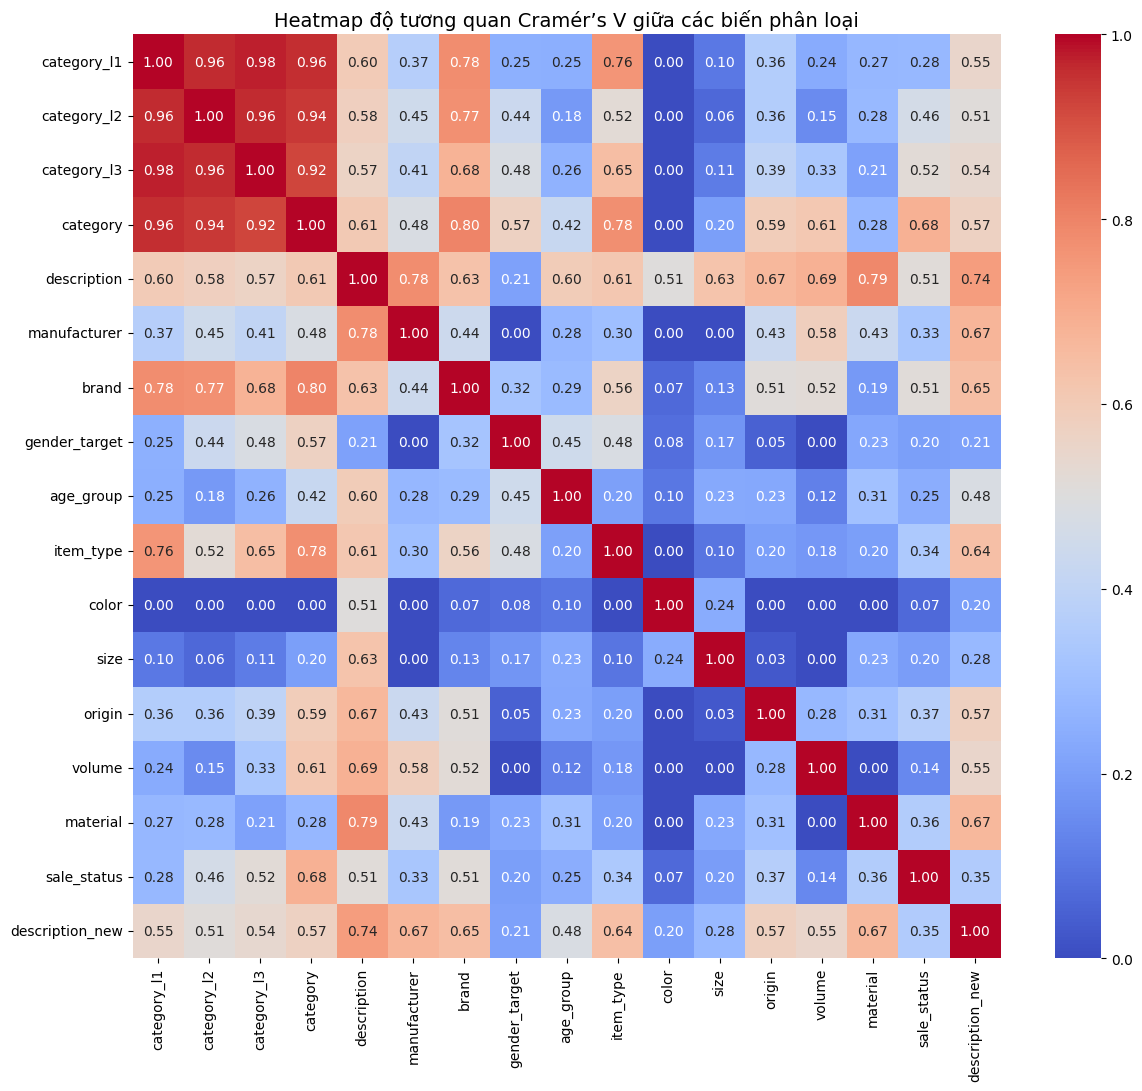

Đã lưu biểu đồ vào: D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\visualize\variate\cramersV_heatmap_full.png


In [19]:
import pandas as pd

from scipy.stats import chi2_contingency


# --- Đọc dữ liệu ---
file_path = r"D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\dataset\sales_pers.item_chunk_0.parquet"
df_item = pl.read_parquet(file_path)

# --- Danh sách cột phân loại ---
cat_cols = [
    "category_l1","category_l2","category_l3", "category", "description",
    "manufacturer", "brand","gender_target", "age_group",
    "item_type", "color", "size", "origin", "volume", "material",
    "sale_status", "description_new"
]
cat_cols = [c for c in cat_cols if c in df_item.columns]

# --- Chuyển sang pandas để xử lý (không dùng pyarrow) ---
df_dict = {col: df_item[col].to_list() for col in cat_cols}
df = pd.DataFrame(df_dict).astype(str).replace("nan", np.nan)

# --- Hàm tính hệ số Cramér’s V ---
def cramers_v(x, y):
    try:
        confusion_matrix = pd.crosstab(x, y)
        if confusion_matrix.shape[0] < 2 or confusion_matrix.shape[1] < 2:
            return np.nan
        chi2 = chi2_contingency(confusion_matrix)[0]
        n = confusion_matrix.sum().sum()
        phi2 = chi2 / n
        r, k = confusion_matrix.shape
        phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
        rcorr = r - ((r-1)**2)/(n-1)
        kcorr = k - ((k-1)**2)/(n-1)
        return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
    except Exception:
        return np.nan

# --- Tính ma trận Cramér’s V ---
cramer_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for c1 in cat_cols:
    for c2 in cat_cols:
        if c1 == c2:
            cramer_matrix.loc[c1, c2] = 1.0
        else:
            cramer_matrix.loc[c1, c2] = cramers_v(df[c1], df[c2])

# --- Vẽ heatmap ---
plt.figure(figsize=(14, 12))
sns.heatmap(
    cramer_matrix.astype(float),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    vmin=0, vmax=1
)
plt.title("Heatmap độ tương quan Cramér’s V giữa các biến phân loại", fontsize=14)

# --- Lưu ảnh ---
output_folder = r"D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\visualize\variate"
os.makedirs(output_folder, exist_ok=True)
save_path = os.path.join(output_folder, "cramersV_heatmap_full.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Đã lưu biểu đồ vào: {save_path}")

### Nhận xét:
- Các feature phân cấp danh mục (category_l1, category_l2, category_l3 và category) có độ tương quan rất cao (>=90%) -> Không nên sử dụng đồng thời tất cả các biến, loại bỏ bớt
- Một số biến có độ tương quan ở mức cao khác như:
    + category_l1 ↔ brand (0.78)
    + item_type ↔ category_l1 (0.76)
    + description ↔ size / material / origin

=> Cần xem xét kĩ để tránh đa cộng tuyến khi huấn luyện mô hình


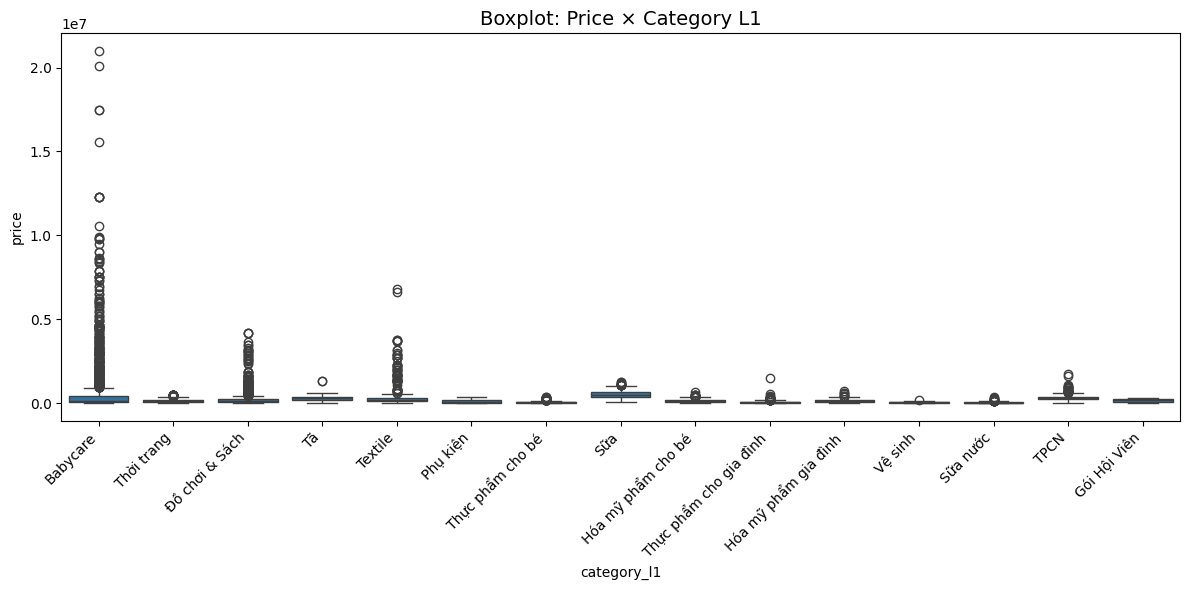

Đã lưu: D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\visualize\variate\price_by_category_l1.png



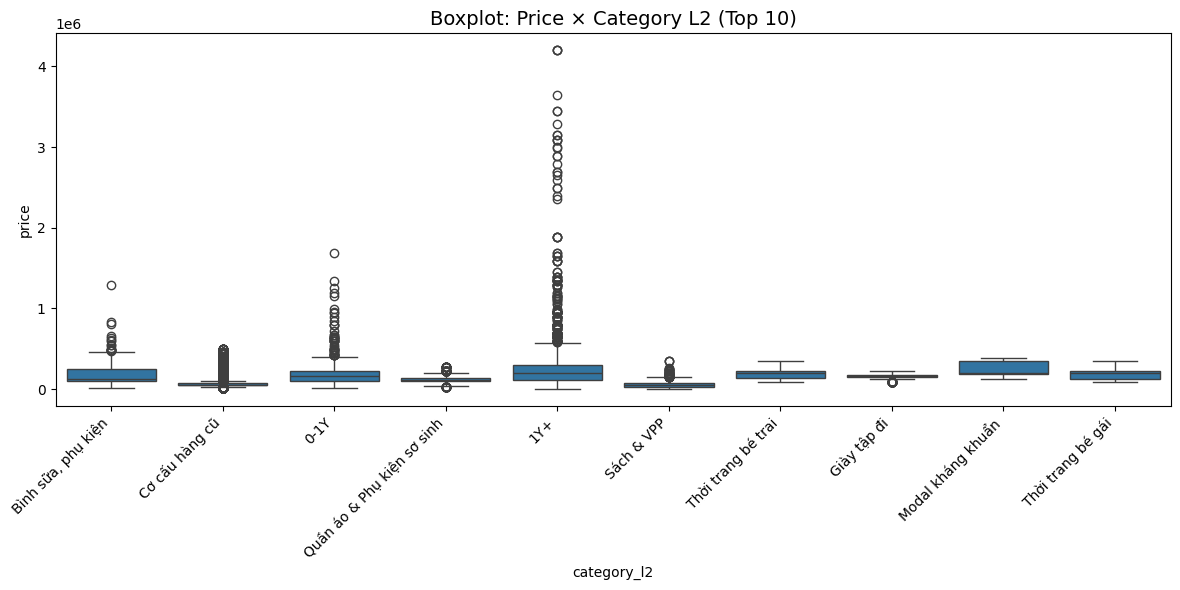

Đã lưu: D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\visualize\variate\price_by_category_l2_top10.png



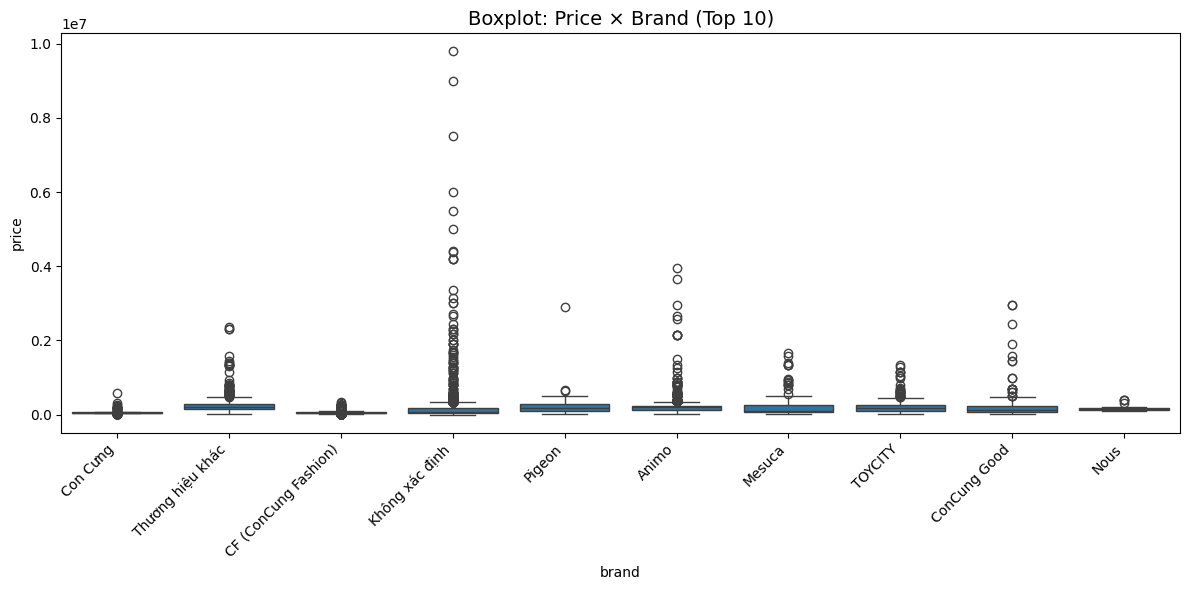

Đã lưu: D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\visualize\variate\price_by_brand_top10.png



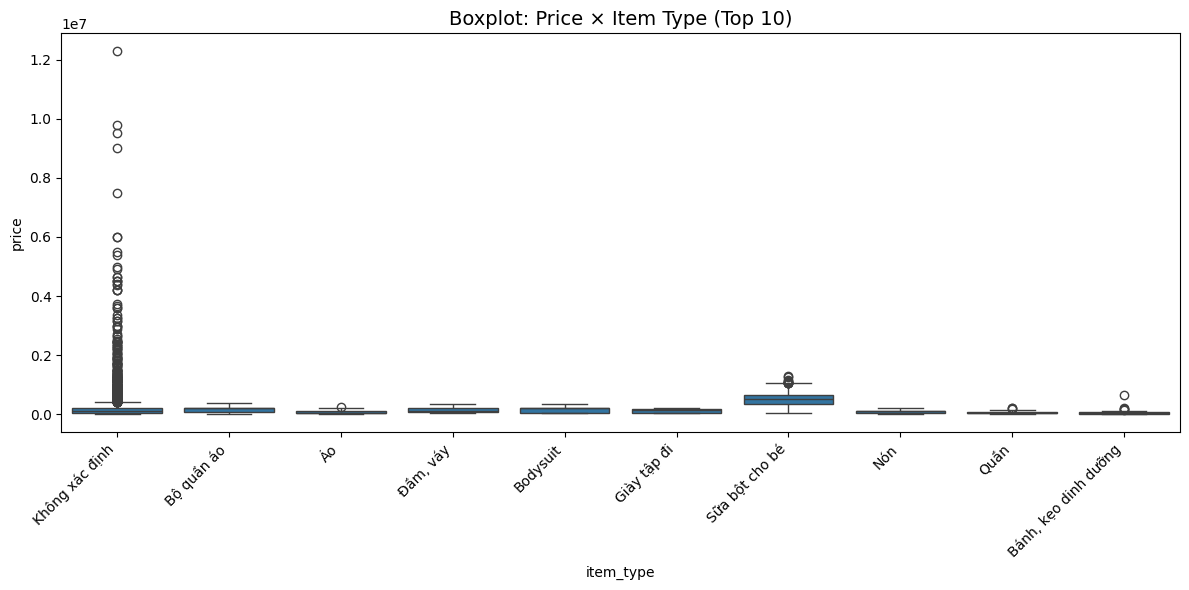

Đã lưu: D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\visualize\variate\price_by_item_type_top10.png



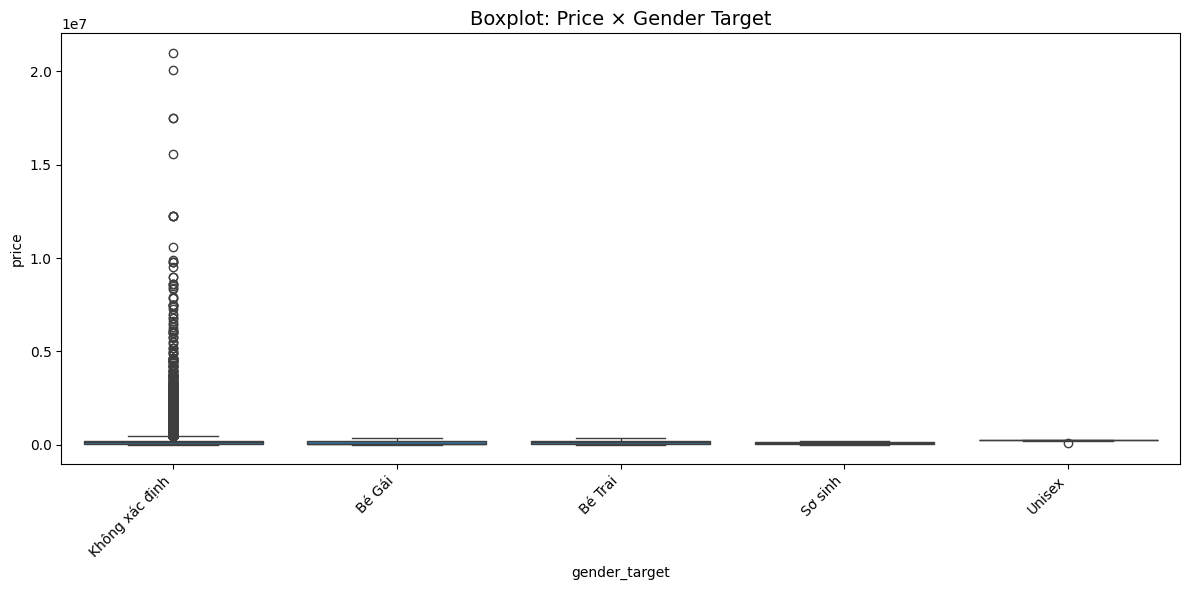

Đã lưu: D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\visualize\variate\price_by_gender_target.png



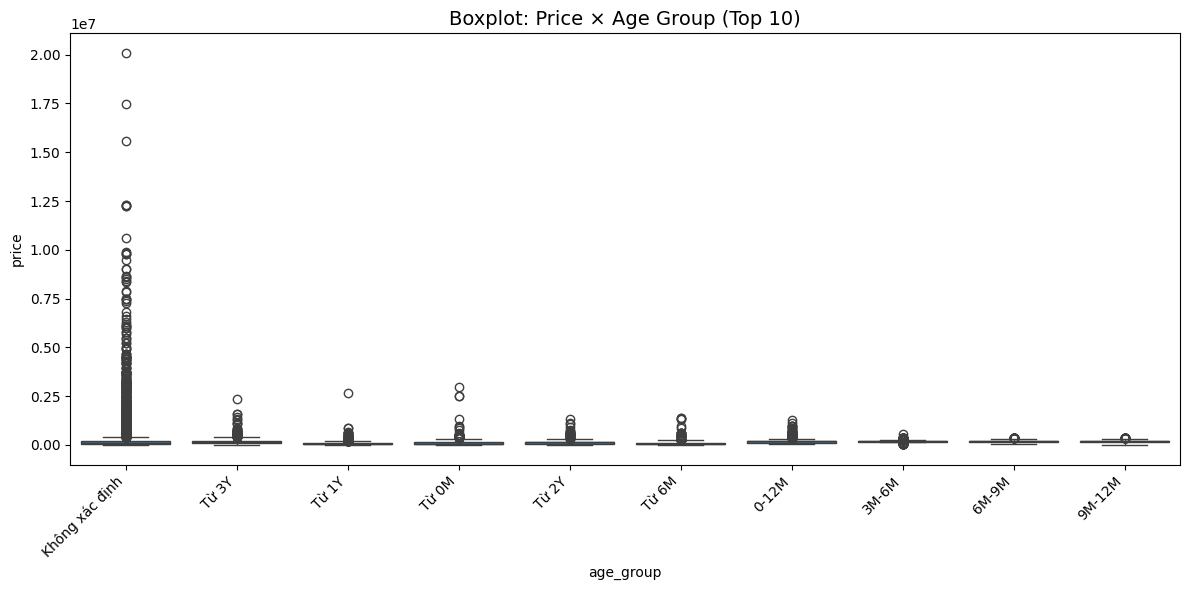

Đã lưu: D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\visualize\variate\price_by_age_group_top10.png



In [20]:
# 1) Convert Polars → Pandas bằng CSV tạm
temp_csv = "_temp_item_chunk.csv"
df_item.write_csv(temp_csv)
df_pd = pd.read_csv(temp_csv)

# 2) Thư mục lưu ảnh
save_dir = r"D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\visualize\variate"
os.makedirs(save_dir, exist_ok=True)


# 3) Hàm boxplot
def plot_boxplot(df, x_col, y_col, title, save_name, top_k=None):

    df_tmp = df.copy()

    # Giữ top K theo tần suất
    if top_k is not None:
        vc = df_tmp[x_col].value_counts().head(top_k).index
        df_tmp = df_tmp[df_tmp[x_col].isin(vc)]

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_tmp, x=x_col, y=y_col)

    plt.title(title, fontsize=14)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    save_path = os.path.join(save_dir, save_name)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Đã lưu: {save_path}\n")


# 4) Vẽ boxplots
plot_boxplot(df_pd, "category_l1", "price", 
             "Boxplot: Price × Category L1", 
             "price_by_category_l1.png")

plot_boxplot(df_pd, "category_l2", "price", 
             "Boxplot: Price × Category L2 (Top 10)", 
             "price_by_category_l2_top10.png", top_k=10)

plot_boxplot(df_pd, "brand", "price",
             "Boxplot: Price × Brand (Top 10)", 
             "price_by_brand_top10.png", top_k=10)

plot_boxplot(df_pd, "item_type", "price",
             "Boxplot: Price × Item Type (Top 10)",
             "price_by_item_type_top10.png", top_k=10)

plot_boxplot(df_pd, "gender_target", "price",
             "Boxplot: Price × Gender Target",
             "price_by_gender_target.png")

plot_boxplot(df_pd, "age_group", "price",
             "Boxplot: Price × Age Group (Top 10)",
             "price_by_age_group_top10.png", top_k=10)


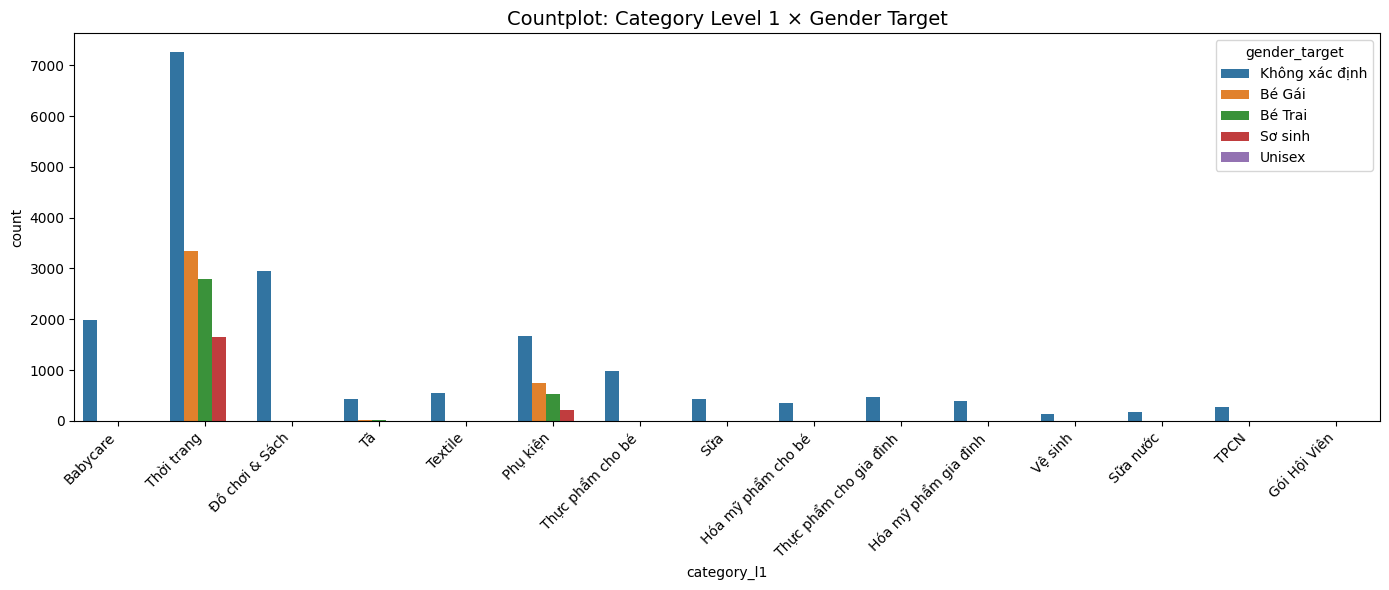

Đã lưu: D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\visualize\variate\countplot_category_l1_gender_target.png



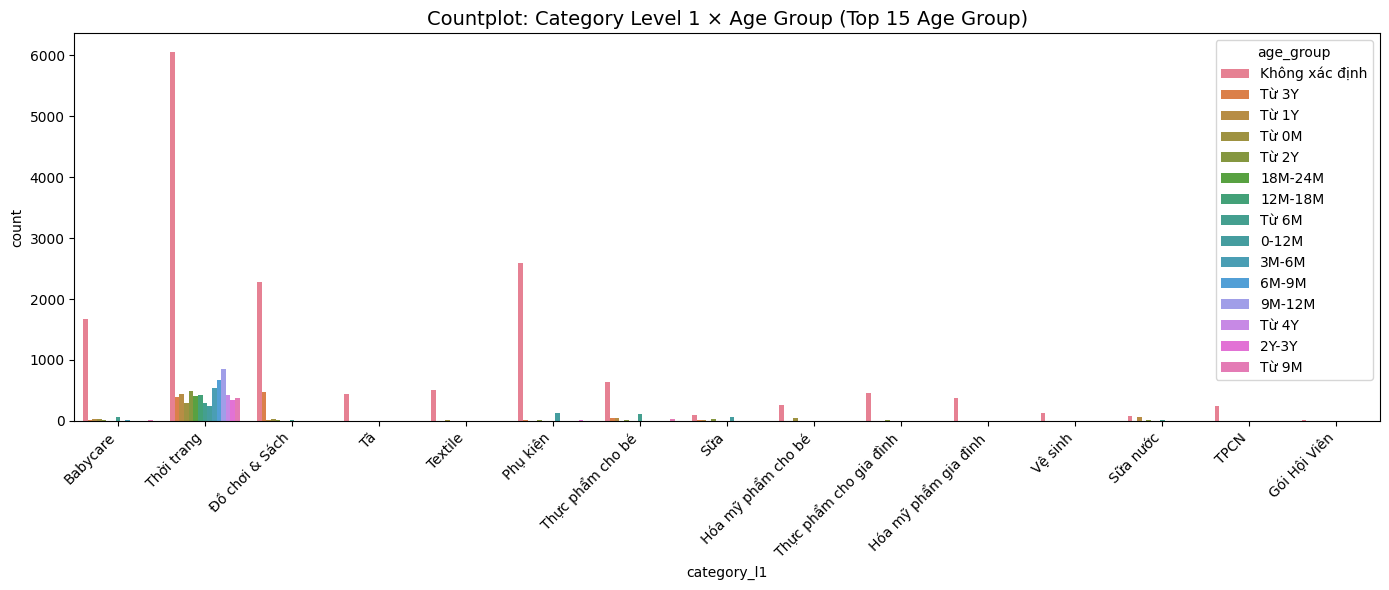

Đã lưu: D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\visualize\variate\countplot_category_l1_age_group_top15.png



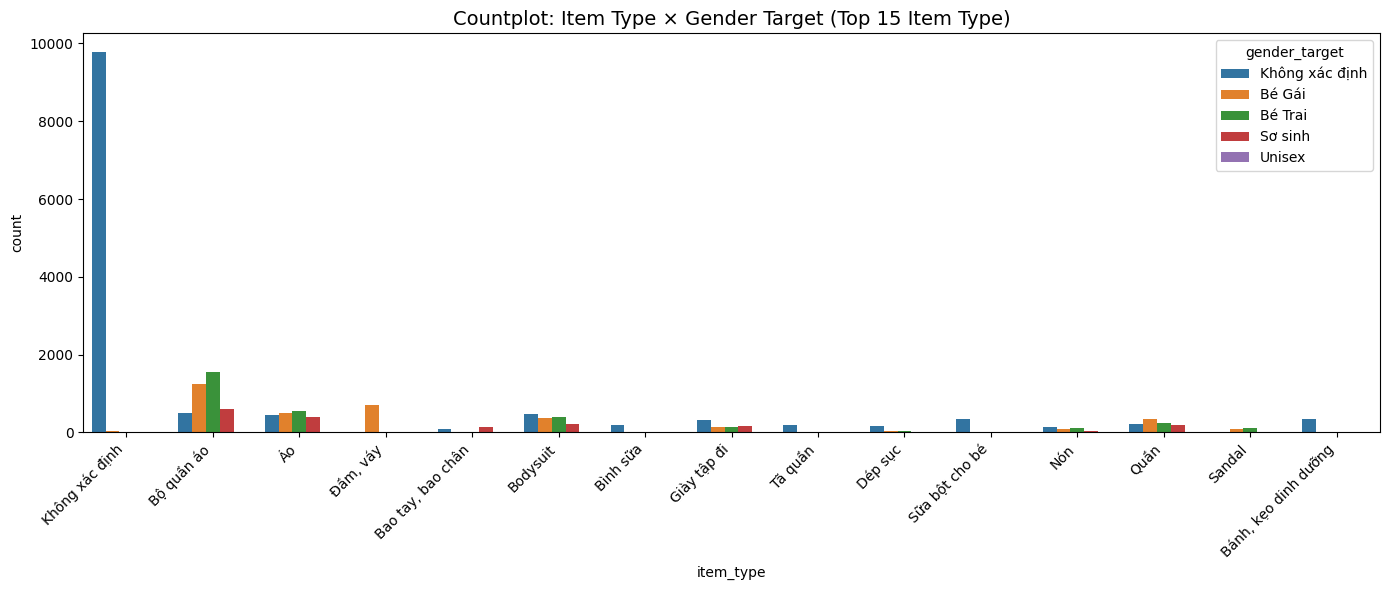

Đã lưu: D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\visualize\variate\countplot_item_type_gender_target_top15.png



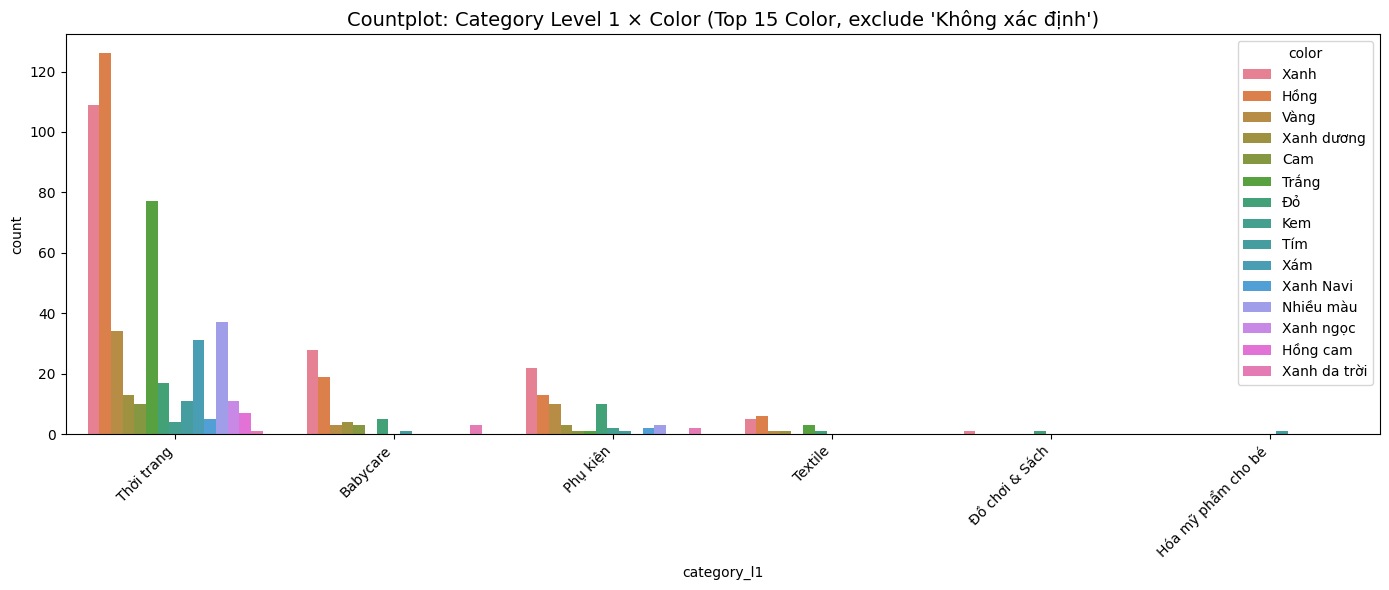

Đã lưu: D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\visualize\variate\countplot_category_l1_color_top15_exclude_unknown.png



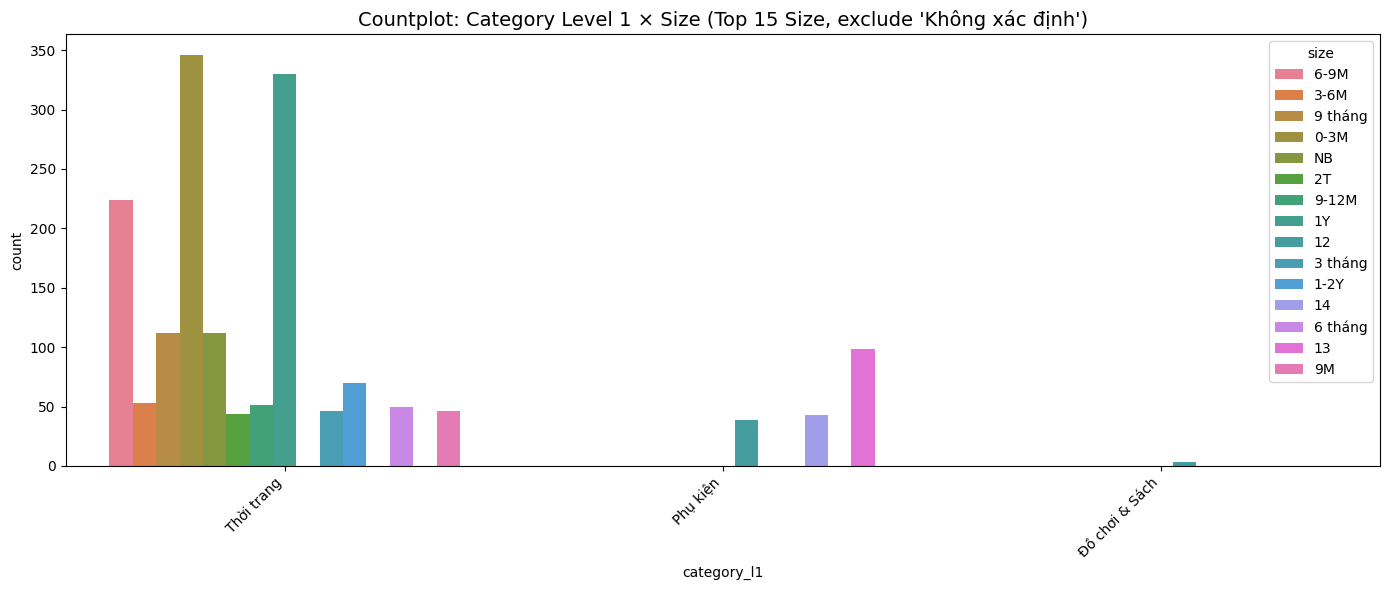

Đã lưu: D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\visualize\variate\countplot_category_l1_size_top15_exclude_unknown.png



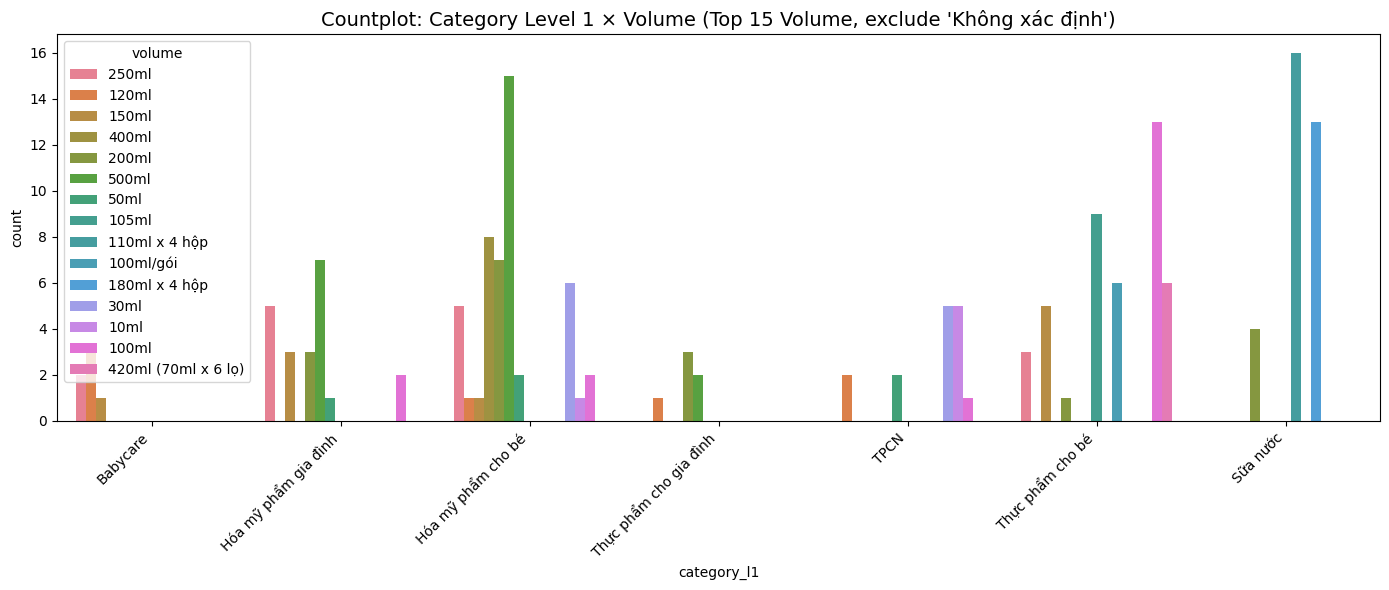

Đã lưu: D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\visualize\variate\countplot_category_l1_volume_top15_exclude_unknown.png



In [21]:
# Thư mục lưu ảnh
save_dir = r"D:\003. HK1 - Năm 3\02. CS116 - Python cho Máy học\CS116-DoAn\Phase-2\visualize\variate"
os.makedirs(save_dir, exist_ok=True)


# ===== Hàm countplot cho categorical × categorical =====
def plot_countplot(df, x_col, hue_col, title, save_name):

    plt.figure(figsize=(14, 6))
    sns.countplot(data=df, x=x_col, hue=hue_col)

    plt.title(title, fontsize=14)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    save_path = os.path.join(save_dir, save_name)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Đã lưu: {save_path}\n")


# 1) CATEGORY_L1 × GENDER_TARGET
plot_countplot(
    df=df_pd,
    x_col="category_l1",
    hue_col="gender_target",
    title="Countplot: Category Level 1 × Gender Target",
    save_name="countplot_category_l1_gender_target.png"
)


# 2) CATEGORY_L1 × AGE_GROUP (TOP 15 AGE_GROUP)
top15_age = df_pd["age_group"].value_counts().head(15).index
df_age_top15 = df_pd[df_pd["age_group"].isin(top15_age)]

plot_countplot(
    df=df_age_top15,
    x_col="category_l1",
    hue_col="age_group",
    title="Countplot: Category Level 1 × Age Group (Top 15 Age Group)",
    save_name="countplot_category_l1_age_group_top15.png"
)


# 3) ITEM_TYPE × GENDER_TARGET (TOP 15 ITEM_TYPE)
top15_item_type = df_pd["item_type"].value_counts().head(15).index
df_itemtype_top15 = df_pd[df_pd["item_type"].isin(top15_item_type)]

plot_countplot(
    df=df_itemtype_top15,
    x_col="item_type",
    hue_col="gender_target",
    title="Countplot: Item Type × Gender Target (Top 15 Item Type)",
    save_name="countplot_item_type_gender_target_top15.png"
)


# 4) CATEGORY_L1 × COLOR (TOP 15 COLORS, BỎ "Không xác định")
mask_color_valid = df_pd["color"] != "Không xác định"
top15_color = df_pd.loc[mask_color_valid, "color"].value_counts().head(15).index
df_color_top15 = df_pd[df_pd["color"].isin(top15_color)]

plot_countplot(
    df=df_color_top15,
    x_col="category_l1",
    hue_col="color",
    title="Countplot: Category Level 1 × Color (Top 15 Color, exclude 'Không xác định')",
    save_name="countplot_category_l1_color_top15_exclude_unknown.png"
)


# 5) CATEGORY_L1 × SIZE (TOP 15 SIZE, BỎ "Không xác định")
mask_size_valid = df_pd["size"] != "Không xác định"
top15_size = df_pd.loc[mask_size_valid, "size"].value_counts().head(15).index
df_size_top15 = df_pd[df_pd["size"].isin(top15_size)]

plot_countplot(
    df=df_size_top15,
    x_col="category_l1",
    hue_col="size",
    title="Countplot: Category Level 1 × Size (Top 15 Size, exclude 'Không xác định')",
    save_name="countplot_category_l1_size_top15_exclude_unknown.png"
)


# 6) CATEGORY_L1 × VOLUME (TOP 15 VOLUME, BỎ "Không xác định")

mask_volume_valid = df_pd["volume"] != "Không xác định"
top15_volume = df_pd.loc[mask_volume_valid, "volume"].value_counts().head(15).index
df_volume_top15 = df_pd[df_pd["volume"].isin(top15_volume)]

plot_countplot(
    df=df_volume_top15,
    x_col="category_l1",
    hue_col="volume",
    title="Countplot: Category Level 1 × Volume (Top 15 Volume, exclude 'Không xác định')",
    save_name="countplot_category_l1_volume_top15_exclude_unknown.png"
)



# **Task 3:** Nhận định sơ bộ 

### **Những trường thông tin nào nên loại bỏ**

**Những trường nào không có nhiều thông tin --> nên loại bỏ**

- Các cột weight, is_deleted, sync_error_message, image_url: tất cả các mẫu đều nhận cùng một giá trị -> Không chứa thông tin phân biệt giữa các mẫu -> vô nghĩa ->  **nên loại bỏ**
- Các cột: 
    + sync_status_id: 26546 giá trị  2  và 786 null
    + sale_status: chỉ có 2 giá trị 0 và 1 
    + volume: 26973 không xác định

    => Không giúp mô hình học được gì

### **Những trường thông tin nào cần xử lý NULL**

- Các cột: 
    + manufacturer: 25767 - không xác định
    + color: 26608 không xác định
    + size: 25108 không xác định
    + material: 24664  không xác định
    + origin: 22627 không xác định
    + gender_target: 18038 Không xác định
    + age_group: 15812 Không xác định
    + brand: 5480 Không xác định

=> Các biến này đều có khả năng đóng vai trò quan trọng trong recommendation vì chúng mô tả đặc điểm sản phẩm mà khách hàng quan tâm (brand, size, age, gender, origin…). Do đó, không thể xoá bỏ mà cần xây dựng chiến lược xử lý missing value phù hợp

- Ngoài ra, các cột: 
    + age_group – phân bố rời rạc, nhiều giá trị hiếm → cần chuẩn hóa
    + price – cần kiểm tra các trường hợp 0đ hoặc 1đ ở min, kiểm tra những giá trị bất thường


**Định hướng xử lý missing value:**
- description và description_new có độ tương đồng trong ma trận tương quan khá cao đối với các feature: manufacturer, color, age_group, .... -> có thể sử dụng để xử lý missing value cho các cột trên.
- Gán nhãn "Other" cho các giá trị nhãn hiếm
- ...

### **Những trường thông tin nào cần xử lý ngoại lệ (Outlier)**

Biến price có nhiều outlier rất mạnh , cần được xử lý 

### **Những trường thông tin nào cần xử lý phân bố không đều**

Có khá nhiều biến phân loại cần xử lý phân bổ lệch như:
- Category_l1 có Thời trang chiếm áp đảo
- category_l2 cũng có Cơ cấu hàng cũ chiếm đa số
- brand: có một thuongw hiệu chiếm phổ biến và rất nhiều thương hiệu hiếm
- age_group có quá nhiều giá trị unique và bị trùng khoảng (ví dụ như 0-6M, 3-6M, 0-12M, 0-1Y)